In [1]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/ImageProcessing/Lab5/'

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
eps = 1e-9

1) Image segmentation using manual global thresholding

In [3]:
def create_his(input):
  his = np.zeros(256, dtype=int)
  for i in range(input.shape[0]):
    for j in range(input.shape[1]):
      gray = input[i,j]
      his[gray] +=1
  return his

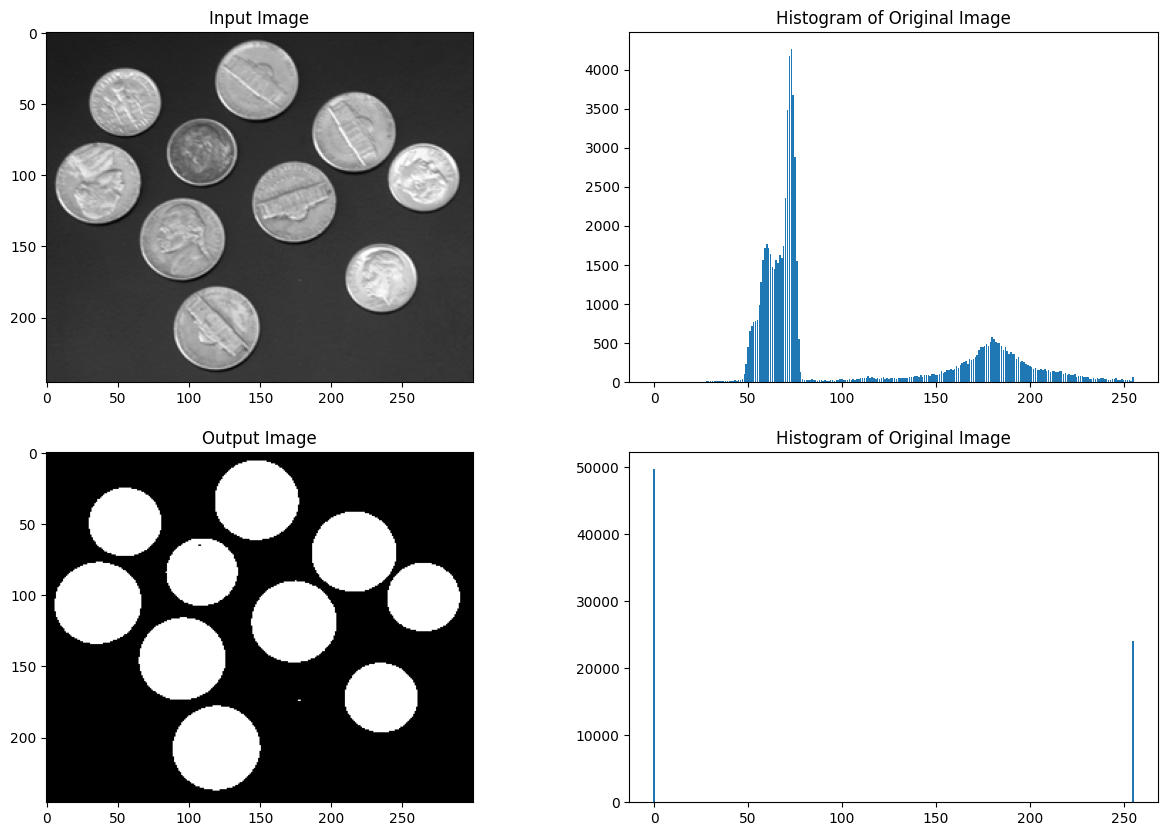

In [4]:
image1_path = path + 'coins.bmp'
image1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)

output_image = np.zeros(image1.shape, dtype=np.uint8)

for i in range(image1.shape[0]):
  for j in range(image1.shape[1]):
      output_image[i,j] = image1[i,j]
      if image1[i,j] < 82:
          output_image[i,j] = 0
      else:
          output_image[i,j] = 255

input_his = create_his(image1)
output_his = create_his(output_image)

plt.figure(figsize=(15,10))

#Histrogram of Original image
plt.subplot(2,2,2)
plt.title('Histogram of Original Image')
plt.bar(np.arange(256), input_his)

#Original Image
plt.subplot(2,2,1)
plt.title('Input Image')
plt.imshow(image1, cmap='gray')

#Histrogram of Output image
plt.subplot(2,2,4)
plt.title('Histogram of Original Image')
plt.bar(np.arange(256), output_his)

#Output image
plt.subplot(2,2,3)
plt.title('Output Image')
plt.imshow(output_image, cmap='gray')

plt.show()

2) Image segmentation usingautomatic global thresholding

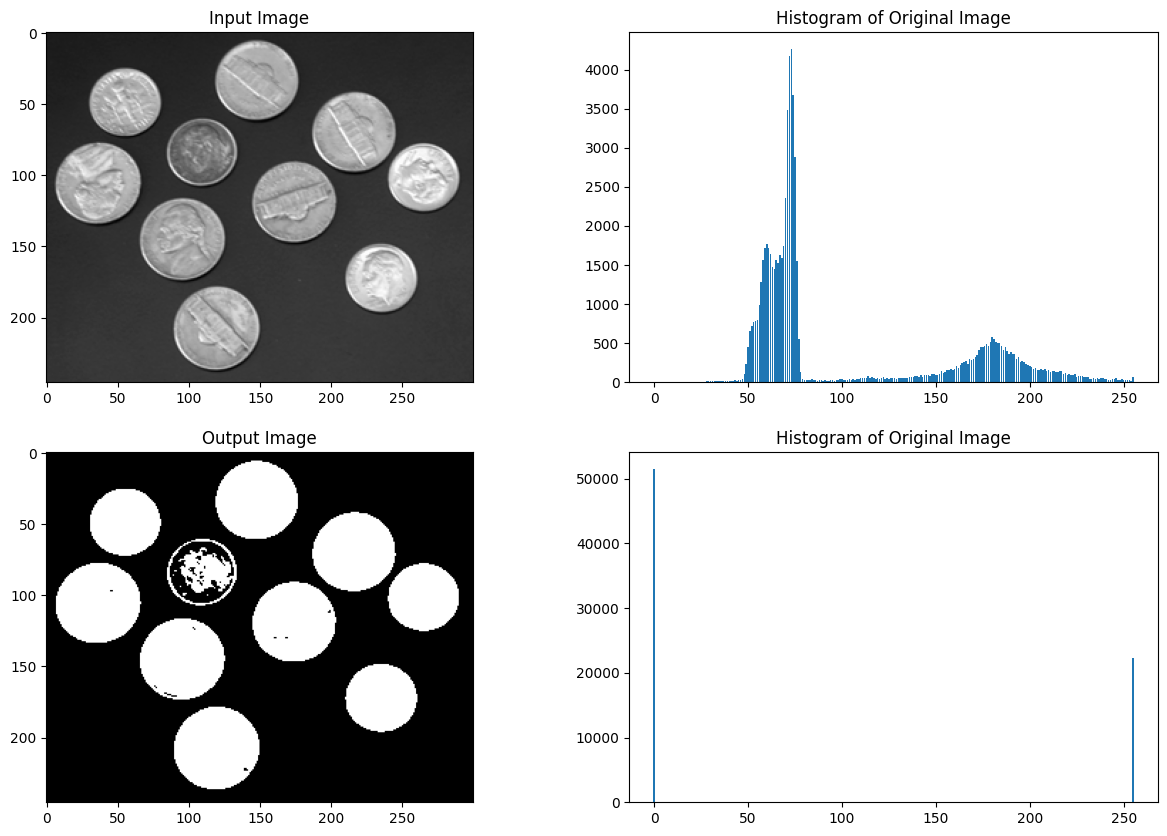

In [5]:
image2_path = path + 'coins.bmp'
image2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

output_image2 = np.zeros(image2.shape, dtype=np.uint8)

threshold = 200
predefined = 0.1

while(True):
  prev_threshold = threshold

  m1 = np.mean(image2[image2 < threshold])
  m2 = np.mean(image2[image2 >= threshold])
  threshold = (m1 + m2) / 2

  if abs(threshold - prev_threshold) < predefined:
    break

for i in range(image1.shape[0]):
  for j in range(image1.shape[1]):
      output_image2[i,j] = image1[i,j]
      if image1[i,j] < threshold:
          output_image2[i,j] = 0
      else:
          output_image2[i,j] = 255

input_his2 = create_his(image2)
output_his2 = create_his(output_image2)


plt.figure(figsize=(15,10))

#Histrogram of Original image
plt.subplot(2,2,2)
plt.title('Histogram of Original Image')
plt.bar(np.arange(256), input_his2)

#Original Image
plt.subplot(2,2,1)
plt.title('Input Image')
plt.imshow(image2, cmap='gray')

#Histrogram of Output image
plt.subplot(2,2,4)
plt.title('Histogram of Original Image')
plt.bar(np.arange(256), output_his2)

#Output image
plt.subplot(2,2,3)
plt.title('Output Image')
plt.imshow(output_image2, cmap='gray')

3) Color image segmentation

In [113]:
def rgb_to_HSV(image_rgb):
    img = image_rgb.astype(np.float32) / 255.0
    r1 = img[:,:,0]
    g1 = img[:,:,1]
    b1 = img[:,:,2]

    v1 = (r1+g1+b1)/3.0

    min = np.minimum(np.minimum(r1, g1), b1)
    sum = r1 + g1 + b1
    s1 = 1.0 - 3.0 * (min / sum)
    s1 = np.where(sum <= eps, 0.0, s1)
    s1 = np.clip(s1, 0.0, 1.0)

    num = 0.5 * ((r1 - g1) + (r1 - b1))
    den = np.sqrt((r1 - g1)**2 + (r1 - b1) * (g1 - b1))
    cos_theta = num / (den + eps)
    theta = np.degrees(np.arccos(cos_theta))

    h1 = np.where(b1 <= g1, theta, 360.0 - theta)
    h1 = h1/360

    h1 = (h1*255).astype(np.uint8)
    s1 = np.clip(s1*255, 0, 255).astype(np.uint8)
    v1 = np.clip(v1*255, 0, 255).astype(np.uint8)

    # print(np.max(h1), np.min(h1))
    # print(np.max(s1), np.min(s1))
    # print(np.max(v1), np.min(v1))

    hsv = np.stack((h1, s1, v1), axis=2)
    return hsv

def HSV_to_rgb(image_hsv):
    image_hsv = image_hsv.astype(np.float32) / 255.0
    h2 = image_hsv[:, :, 0]
    s2 = image_hsv[:, :, 1]
    v2 = image_hsv[:, :, 2]

    R = np.zeros(h2.shape, dtype=np.float32)
    G = np.zeros(h2.shape, dtype=np.float32)
    B = np.zeros(h2.shape, dtype=np.float32)

    for i in range(h2.shape[0]):
        for j in range(h2.shape[1]):
            H = h2[i, j]
            S = s2[i, j]
            V = v2[i, j]

            H = H * 360

            if 0 <= H < 120:
              b2 = V*(1-S)
              r2 = V*(1+(S*np.cos(H*np.pi/180))/(np.cos((60-H)*np.pi/180)))
              g2 = 3*V - r2 - b2
            elif 120 < H <= 240:
              H = H - 120
              r2 = V*(1-S)
              g2 = V*(1+(S*np.cos(H*np.pi/180))/(np.cos((60-H)*np.pi/180)))
              b2 = 3*V - r2 - g2
            else:
              H = H - 240
              g2 = V*(1-S)
              b2 = V*(1+(S*np.cos(H*np.pi/180))/(np.cos((60-H)*np.pi/180)))
              r2 = 3*V - g2 - b2

            R[i,j] = r2*255
            G[i,j] = g2*255
            B[i,j] = b2*255

    # print(np.max(h2), np.min(h2))
    # print(np.max(s2), np.min(s2))
    # print(np.max(v2), np.min(v2))

    rgb_output = np.zeros(image_hsv.shape, dtype=np.uint8)
    rgb_output[:,:,0] = np.clip(R, 0, 255).astype(np.uint8)
    rgb_output[:,:,1] = np.clip(G, 0, 255).astype(np.uint8)
    rgb_output[:,:,2] = np.clip(B, 0, 255).astype(np.uint8)

    return rgb_output

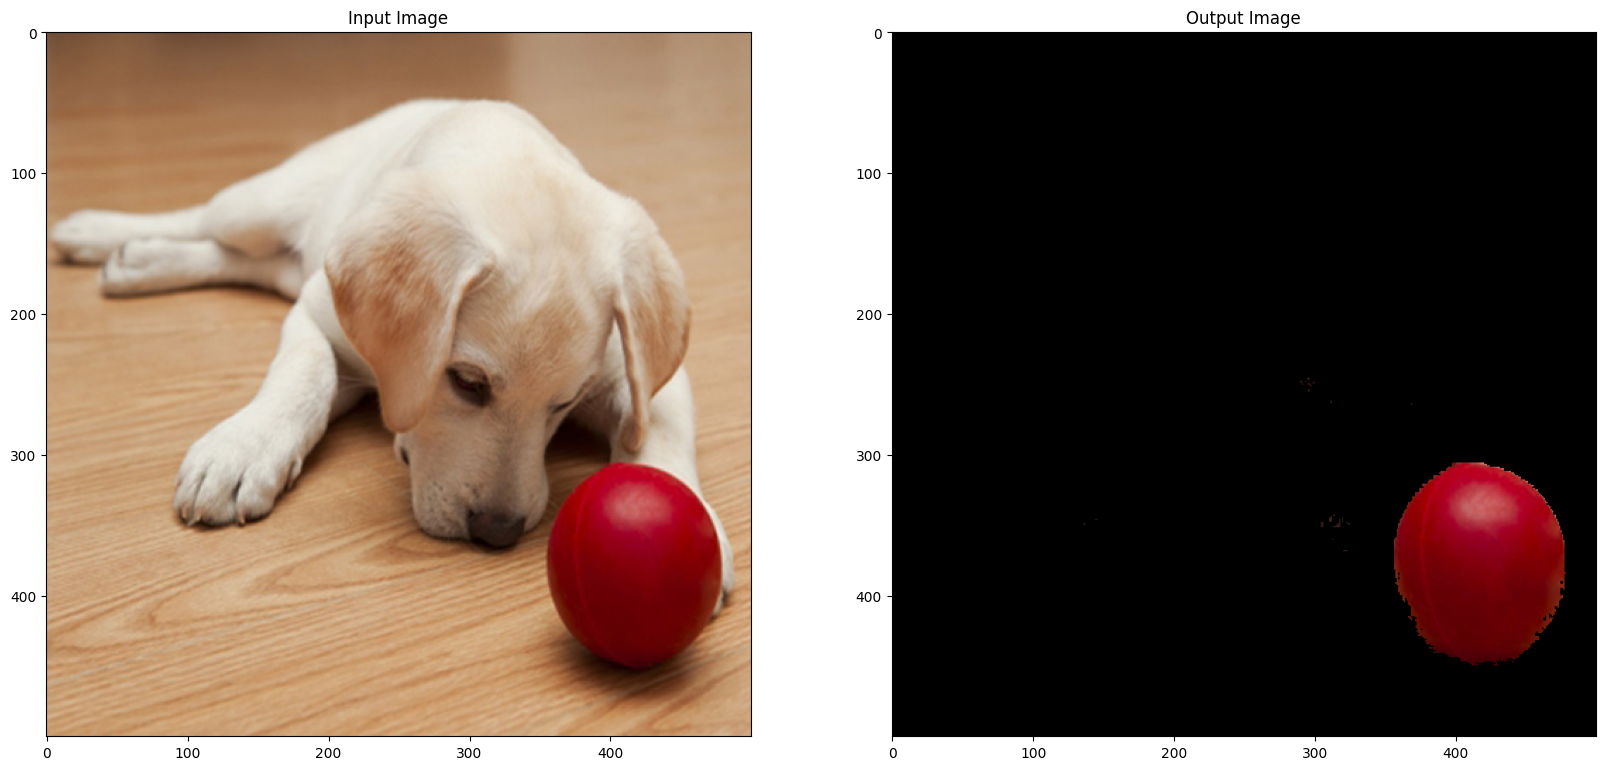

In [169]:
image3_path = path + 'PuppyWithBall.jpg'
image3 = cv2.imread(image3_path, cv2.IMREAD_COLOR)

image3 = image3[:, :, ::-1]

output_image3 = np.zeros(image3.shape, dtype=np.uint8)

hsv_image1 = rgb_to_HSV(image3)
h = hsv_image1[:, :, 0]
s = hsv_image1[:, :, 1]
v = hsv_image1[:, :, 2]

output_hue = np.zeros(h.shape, dtype=np.uint8)

condition = ((h <= 6) | (h >= 244)) & (s >= 57) & (v >= 25)

for i in range(image3.shape[0]):
  for j in range(image3.shape[1]):
      if condition[i,j]:
            output_hue[i, j] = h[i, j]
            s[i, j] = s[i, j]
            v[i, j] = v[i, j]
      else:
            output_hue[i, j] = h[i, j]
            v[i, j] = 0
            s[i, j] = 0

output_hsv = np.stack((output_hue, s, v), axis=2)
output_image3 = HSV_to_rgb(output_hsv)

plt.figure(figsize=(20,20))

#Original Image
plt.subplot(1,2,1)
plt.title('Input Image')
plt.imshow(image3)

#Output image
plt.subplot(1,2,2)
plt.title('Output Image')
plt.imshow(output_image3, cmap='gray')
